# Hawkes/SVMHJD Model Comparison

Report notebook for comparing registered continuous and discrete Hawkes/SVMHJD research candidates. The notebook is read-only with respect to model artefacts by default: it loads registry metadata and optional local summaries, prints commands for missing artefacts, and does not train or evaluate full models unless the run flags are changed deliberately.


## 1. Benchmark overview

Hawkes/SVMHJD is registered as a research-candidate scenario-data benchmark. The comparison focuses on the repaired continuous log-return baseline, the hidden128 log-return cb64 tokenizer, the required additive AR prior ablation, the causal conv-transformer k3 prior selected under the balanced/smooth research profile, and the optional tiny conv-transformer efficiency candidate. Lower values are better for path-distribution and Wasserstein-style metrics; token active-code and perplexity values describe utilisation rather than an optimisation target.


In [1]:
from __future__ import annotations

import json
import os
import shlex
import sys
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "report"
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-time-causal-vae")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Markdown, display

from time_causal_vae.evaluation.jump_diagnostics import detect_jumps_from_returns
from time_causal_vae.evaluation.market_diagnostics import compute_log_returns
from time_causal_vae.evaluation.model_profile import ModelProfileSpec, profile_model_specs
from time_causal_vae.experiments.model_registry import load_registry, select_registered_model

try:
    from torchview import draw_graph as torchview_draw_graph
except Exception:  # pragma: no cover - optional notebook dependency.
    torchview_draw_graph = None

try:
    from scipy.spatial import Voronoi, voronoi_plot_2d
except Exception:  # pragma: no cover - optional geometry helper.
    Voronoi = None
    voronoi_plot_2d = None

try:
    from sklearn.decomposition import PCA
except Exception:  # pragma: no cover - use the SVD fallback in that case.
    PCA = None

AUTO_SELECT_MODEL = True
MODEL_REGISTRY_PATH = "../../trained_models/model_registry.yaml"
RUN_SMOKE = True
RUN_FULL = False
RUN_TRAINING = False
RUN_EVALUATION = False
RUN_HEAVY = False
RUN_EXPENSIVE_METRICS = False
RUN_SIGNATURE_KERNEL = False
RUN_ADAPTED_WASSERSTEIN = False
ALLOW_MISSING_OUTPUTS = True
USE_LOCAL_OUTPUTS = True

EXPERIMENT_ID = "hawkes_jump"
MODEL_SELECTION_PROFILE = "research_candidate"
SEED = 0
N_SAMPLE_SMOKE = 256
N_SAMPLE_FULL = 1024
N_SAMPLE = N_SAMPLE_FULL if RUN_FULL else N_SAMPLE_SMOKE
FULL_EVAL_N_SAMPLE = 1024
PROFILE_BATCH_SIZE = 64
PROFILE_WARMUP_RUNS = 1
PROFILE_REPEATS = 3
PROFILE_DEVICE = "cpu"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

print(f"repo_root={REPO_ROOT}")
print(f"torchview_available={torchview_draw_graph is not None}")
print(f"run_training={RUN_TRAINING}")
print(f"run_evaluation={RUN_EVALUATION}")

repo_root=/home/georgios-vourvachakis/Desktop/TimeCausalVQVAE
torchview_available=True
run_training=False
run_evaluation=False


In [2]:
def repo_path(path: str | Path) -> Path:
    """Resolve a repository-relative path."""
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


def resolve_parameter_path(path: str | Path) -> Path:
    """Resolve a parameter path from the notebook directory, then the repo root."""
    raw_path = Path(path)
    if raw_path.is_absolute():
        return raw_path
    notebook_relative = (NOTEBOOK_DIR / raw_path).resolve()
    if notebook_relative.exists():
        return notebook_relative
    repo_relative = (REPO_ROOT / raw_path).resolve()
    if repo_relative.exists():
        return repo_relative
    return notebook_relative


def display_path(path: str | Path) -> str:
    """Render paths compactly when they are inside the repository."""
    path = Path(path)
    try:
        return str(path.resolve().relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


def read_json_if_present(path: str | Path) -> dict[str, Any] | None:
    """Load a JSON mapping if it exists and is valid."""
    resolved = repo_path(path)
    if not resolved.exists():
        return None
    with resolved.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    return payload if isinstance(payload, dict) else None


def read_yaml_if_present(path: str | Path) -> dict[str, Any] | None:
    """Load a YAML mapping if it exists and is valid."""
    resolved = repo_path(path)
    if not resolved.exists():
        return None
    with resolved.open("r", encoding="utf-8") as handle:
        payload = yaml.safe_load(handle) or {}
    return payload if isinstance(payload, dict) else None


def numeric_or_none(value: Any) -> float | None:
    """Convert scalar metric values to floats when possible."""
    if value is None:
        return None
    if isinstance(value, bool):
        return float(value)
    if isinstance(value, int | float | np.number):
        return float(value)
    if isinstance(value, torch.Tensor) and value.numel() == 1:
        return float(value.detach().cpu())
    return None


def metric_from_mapping(metrics: Mapping[str, Any], aliases: Sequence[str]) -> float | None:
    """Read a metric by the first available alias."""
    for alias in aliases:
        value = metrics.get(alias)
        if isinstance(value, Mapping) and "mean" in value:
            return numeric_or_none(value.get("mean"))
        converted = numeric_or_none(value)
        if converted is not None:
            return converted
    return None


def metric_std_from_mapping(metrics: Mapping[str, Any], aliases: Sequence[str]) -> float | None:
    """Read a metric standard deviation from either aggregate or *_std keys."""
    for alias in aliases:
        value = metrics.get(alias)
        if isinstance(value, Mapping) and "std" in value:
            return numeric_or_none(value.get("std"))
        converted = numeric_or_none(metrics.get(f"{alias}_std"))
        if converted is not None:
            return converted
    return None


def format_metric(value: float | None, std: float | None = None) -> str:
    """Format metric values compactly for report tables."""
    if value is None:
        return ""
    if std is None:
        return f"{value:.4g}"
    return f"{value:.4g} +/- {std:.2g}"


def shell_join(parts: Sequence[str]) -> str:
    """Render a shell command from argument parts."""
    return shlex.join([str(part) for part in parts])

## 2. Load registered Hawkes continuous/discrete metadata if available

The metadata registry is authoritative for candidate identifiers, selected configs, sampling policy, current metrics, and caveats. Notebook code uses the registry-selected k3 discrete model by default; no code change is needed unless a user explicitly chooses another candidate or profile. Local checkpoints and output summaries remain outside Git.


In [3]:
registry_path = resolve_parameter_path(MODEL_REGISTRY_PATH)
registry = load_registry(registry_path) if AUTO_SELECT_MODEL and registry_path.exists() else {}
hawkes_registry = registry.get("experiments", {}).get(EXPERIMENT_ID, {}) if registry else {}

if not hawkes_registry:
    display(
        Markdown(f"No `{EXPERIMENT_ID}` registry entry found at `{display_path(registry_path)}`.")
    )
else:
    display(Markdown(f"Loaded registry entry from `{display_path(registry_path)}`."))

registered_models: dict[str, Any] = {}
if hawkes_registry and AUTO_SELECT_MODEL:
    try:
        registered_models["continuous"] = select_registered_model(
            registry,
            experiment=EXPERIMENT_ID,
            family="continuous",
            profile=MODEL_SELECTION_PROFILE,
        )
    except Exception as exc:
        print(f"Continuous registry selection unavailable: {exc}")
    try:
        registered_models["discrete_selected"] = select_registered_model(
            registry,
            experiment=EXPERIMENT_ID,
            family="discrete",
            profile=MODEL_SELECTION_PROFILE,
        )
    except Exception as exc:
        print(f"Discrete registry selection unavailable: {exc}")

discrete_section = (
    hawkes_registry.get("discrete", {}) if isinstance(hawkes_registry, Mapping) else {}
)
discrete_candidates = (
    discrete_section.get("candidates", {}) if isinstance(discrete_section, Mapping) else {}
)
required_ablation_id = (
    discrete_section.get("required_ablation") if isinstance(discrete_section, Mapping) else None
)
required_ablation = (
    discrete_candidates.get(required_ablation_id)
    if isinstance(discrete_candidates, Mapping) and isinstance(required_ablation_id, str)
    else None
)

registry_rows = []
if "continuous" in registered_models:
    model = registered_models["continuous"]
    registry_rows.append(
        {
            "role": "continuous log-return baseline",
            "family": model.family,
            "candidate": model.candidate_id,
            "selected_by": model.selected_by,
            "config": model.config,
            "tokenizer_config": model.tokenizer_config,
            "prior_config": model.prior_config,
            "checkpoint_convention": model.candidate.get("checkpoint_convention"),
            "status": model.candidate.get("status"),
        }
    )
if required_ablation is not None:
    registry_rows.append(
        {
            "role": "required additive AR ablation",
            "family": "discrete",
            "candidate": required_ablation_id,
            "selected_by": "discrete.required_ablation",
            "config": None,
            "tokenizer_config": required_ablation.get("tokenizer_config"),
            "prior_config": required_ablation.get("prior_config"),
            "checkpoint_convention": required_ablation.get("checkpoint_convention"),
            "status": required_ablation.get("status"),
        }
    )
if "discrete_selected" in registered_models:
    model = registered_models["discrete_selected"]
    registry_rows.append(
        {
            "role": "selected conv-transformer k3 prior",
            "family": model.family,
            "candidate": model.candidate_id,
            "selected_by": model.selected_by,
            "config": model.config,
            "tokenizer_config": model.tokenizer_config,
            "prior_config": model.prior_config,
            "checkpoint_convention": model.candidate.get("checkpoint_convention"),
            "status": model.candidate.get("status"),
        }
    )

display(pd.DataFrame(registry_rows))

Loaded registry entry from `trained_models/model_registry.yaml`.

,role,family,candidate,selected_by,config,tokenizer_config,prior_config,checkpoint_convention,status
0,continuous log-return baseline,continuous,beta_cvae_logreturn_identity,explicit_selected,configs/experiments/hawkes_jump_beta_cvae_logr...,None,None,outputs/hawkes_jump_continuous_logreturn_ident...,research_candidate
1,required additive AR ablation,discrete,hidden128_logreturn_cb64_additive_ar,discrete.required_ablation,None,configs/experiments/hawkes_jump_causal_vq_toke...,configs/experiments/hawkes_jump_causal_token_p...,outputs/hawkes_jump_logreturn_robustness/,research_candidate
2,selected conv-transformer k3 prior,discrete,hidden128_logreturn_cb64_conv_transformer_k3,explicit_selected,None,configs/experiments/hawkes_jump_causal_vq_toke...,configs/experiments/hawkes_jump_causal_token_p...,outputs/hawkes_jump_logreturn_robustness/,research_candidate


## 3. Print selected configs and sampling policy

The configs below are printed for auditability. Missing local files are reported without failing the notebook.


In [4]:
config_paths = []
for row in registry_rows:
    for key in ("config", "tokenizer_config", "prior_config"):
        value = row.get(key)
        if isinstance(value, str) and value not in config_paths:
            config_paths.append(value)

config_rows = []
for path in config_paths:
    payload = read_yaml_if_present(path)
    config_rows.append(
        {
            "config": path,
            "exists": repo_path(path).exists(),
            "experiment": (payload or {}).get("experiment", {}).get("name"),
            "dataset": (payload or {}).get("experiment", {}).get("dataset"),
            "seed": (payload or {}).get("experiment", {}).get("seed"),
            "model_family": (payload or {}).get("model", {}).get("family")
            or (payload or {}).get("model", {}).get("objective"),
            "data_output": (payload or {}).get("data", {}).get("params", {}).get("data_output")
            or (payload or {}).get("data", {}).get("data_params", {}).get("data_output")
            or (payload or {}).get("data", {}).get("data_output"),
            "simulation_scheme": (payload or {})
            .get("data", {})
            .get("params", {})
            .get("simulation_scheme")
            or (payload or {}).get("data", {}).get("data_params", {}).get("simulation_scheme"),
            "epochs": (payload or {}).get("training", {}).get("epochs"),
        }
    )

display(pd.DataFrame(config_rows))

sampling_rows = []
experiment_sampling = (
    hawkes_registry.get("sampling_policy", {}) if isinstance(hawkes_registry, Mapping) else {}
)
if experiment_sampling:
    sampling_rows.append({"source": "experiment", **dict(experiment_sampling)})
for key, model in registered_models.items():
    if getattr(model, "sampling", None):
        sampling_rows.append({"source": key, "candidate": model.candidate_id, **model.sampling})
if required_ablation is not None and isinstance(required_ablation.get("sampling"), Mapping):
    sampling_rows.append(
        {
            "source": "required_ablation",
            "candidate": required_ablation_id,
            **dict(required_ablation["sampling"]),
        }
    )

display(pd.DataFrame(sampling_rows))

,config,exists,experiment,dataset,seed,model_family,data_output,simulation_scheme,epochs
0,configs/experiments/hawkes_jump_beta_cvae_logr...,True,hawkes_jump_beta_cvae_logreturn_identity,hawkes_jump,0,beta_cvae,log_return,ogata,2
1,configs/experiments/hawkes_jump_causal_vq_toke...,True,hawkes_jump_causal_vq_tokenizer_hidden128_logr...,hawkes_jump,0,causal_vq_tokenizer,log_return,ogata,2
2,configs/experiments/hawkes_jump_causal_token_p...,True,hawkes_jump_causal_token_prior_hidden128_logre...,hawkes_jump,0,causal_token_prior,log_return,None,2
3,configs/experiments/hawkes_jump_causal_token_p...,True,hawkes_jump_causal_token_prior_hidden128_logre...,hawkes_jump,0,causal_token_prior,log_return,None,2


,source,temperature,top_k,applies_to,candidate,condition_policy
0,experiment,1.0,None,discrete_token_prior,NaN,NaN
1,discrete_selected,1.0,None,NaN,hidden128_logreturn_cb64_conv_transformer_k3,constant_condition_log_return_prior
2,required_ablation,1.0,None,NaN,hidden128_logreturn_cb64_additive_ar,constant_condition_log_return_prior


## 4. Parameter Count and Inference-Time Profile

The table below profiles the report-comparison architectures from their selected YAML configs. The timing benchmark uses randomly initialised weights on the configured device, so it measures architecture cost rather than checkpoint quality.


In [5]:
profile_specs = []
if "continuous" in registered_models:
    model = registered_models["continuous"]
    profile_specs.append(
        ModelProfileSpec(
            role="Continuous BetaCVAE",
            family="continuous",
            model=model.candidate_id,
            config=model.config,
        )
    )
if required_ablation is not None:
    profile_specs.append(
        ModelProfileSpec(
            role="Additive AR ablation",
            family="discrete",
            model=str(required_ablation_id),
            tokenizer_config=required_ablation.get("tokenizer_config"),
            prior_config=required_ablation.get("prior_config"),
            sampling=required_ablation.get("sampling"),
        )
    )
if "discrete_selected" in registered_models:
    model = registered_models["discrete_selected"]
    profile_specs.append(
        ModelProfileSpec(
            role="Selected conv-transformer k3 prior",
            family="discrete",
            model=model.candidate_id,
            tokenizer_config=model.tokenizer_config,
            prior_config=model.prior_config,
            sampling=model.sampling,
        )
    )

if profile_specs:
    profile_table = pd.DataFrame(
        profile_model_specs(
            profile_specs,
            repo_root=REPO_ROOT,
            batch_size=PROFILE_BATCH_SIZE,
            warmup_runs=PROFILE_WARMUP_RUNS,
            repeats=PROFILE_REPEATS,
            device=PROFILE_DEVICE,
            seed=SEED,
        )
    )
    display(profile_table)
else:
    display(Markdown("No registered model configs were available for profiling."))

,role,family,model,parameters,parameters_millions,tokenizer_parameters,token_prior_parameters,benchmark_batch_size,inference_mean_ms,inference_std_ms,inference_ms_per_path,device,timed_operation,source
0,Continuous BetaCVAE,continuous,beta_cvae_logreturn_identity,202989,0.202989,NaN,NaN,64,1.802646,0.242954,0.028166,cpu,continuous generation,"YAML architecture, randomly initialised weights"
1,Additive AR ablation,discrete,hidden128_logreturn_cb64_additive_ar,621649,0.621649,332177.0,289472.0,64,1176.056006,34.286239,18.375875,cpu,token-prior sampling plus tokenizer decode,"YAML architecture, randomly initialised weights"
2,Selected conv-transformer k3 prior,discrete,hidden128_logreturn_cb64_conv_transformer_k3,720721,0.720721,332177.0,388544.0,64,1312.540548,7.287980,20.508446,cpu,token-prior sampling plus tokenizer decode,"YAML architecture, randomly initialised weights"


## 5. Load local evaluation summaries if present

Local outputs are optional. When `USE_LOCAL_OUTPUTS=True`, the notebook looks for seed-robust aggregate summaries and representative seed-0 batches under ignored `outputs/` paths.


In [6]:
LOCAL_SUMMARY_PATHS = {
    "matched_aggregate": Path(
        "outputs/hawkes_jump_matched_continuous_comparison/aggregate_summary.json"
    ),
    "continuous_ablation_aggregate": Path(
        "outputs/hawkes_jump_continuous_ablation_comparison/aggregate_summary.json"
    ),
    "logreturn_robustness_manifest": Path(
        "outputs/hawkes_jump_logreturn_robustness/aggregate_summary.json"
    ),
    "continuous_seed0": Path(
        "outputs/hawkes_jump_continuous_logreturn_identity/seed0/evaluation/evaluation_summary.json"
    ),
    "additive_seed0": Path(
        "outputs/hawkes_jump_logreturn_robustness/evaluations/additive_seed0/evaluation_summary.json"
    ),
    "conv_transformer_seed0": Path(
        "outputs/hawkes_jump_logreturn_robustness/evaluations/conv_transformer_seed0/evaluation_summary.json"
    ),
    "tokenizer_seed0": Path(
        "outputs/hawkes_jump_logreturn_robustness/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0/codebook_summary.json"
    ),
    "token_data_seed0": Path(
        "outputs/hawkes_jump_logreturn_robustness/tokens/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0/token_dataset_summary.json"
    ),
}
LOCAL_BATCH_PATHS = {
    "continuous_beta_cvae": Path(
        "outputs/hawkes_jump_continuous_logreturn_identity/seed0/evaluation/evaluation_batch.pt"
    ),
    "additive_ar": Path(
        "outputs/hawkes_jump_logreturn_robustness/evaluations/additive_seed0/evaluation_batch.pt"
    ),
    "conv_transformer_k3": Path(
        "outputs/hawkes_jump_logreturn_robustness/evaluations/conv_transformer_seed0/evaluation_batch.pt"
    ),
}
TOKENIZER_DIR = Path(
    "outputs/hawkes_jump_logreturn_robustness/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0"
)
TOKEN_DATA_DIR = Path(
    "outputs/hawkes_jump_logreturn_robustness/tokens/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0"
)

local_summaries: dict[str, dict[str, Any]] = {}
summary_inventory = []
for name, path in LOCAL_SUMMARY_PATHS.items():
    exists = USE_LOCAL_OUTPUTS and repo_path(path).exists()
    summary_inventory.append(
        {
            "name": name,
            "path": display_path(repo_path(path)),
            "exists": exists,
        }
    )
    if exists:
        payload = read_json_if_present(path)
        if payload is not None:
            local_summaries[name] = payload

batch_inventory = []
for name, path in LOCAL_BATCH_PATHS.items():
    batch_inventory.append(
        {
            "name": name,
            "path": display_path(repo_path(path)),
            "exists": USE_LOCAL_OUTPUTS and repo_path(path).exists(),
        }
    )

display(Markdown("### Summary inventory"))
display(pd.DataFrame(summary_inventory))
display(Markdown("### Batch inventory"))
display(pd.DataFrame(batch_inventory))

### Summary inventory

,name,path,exists
0,matched_aggregate,outputs/hawkes_jump_matched_continuous_compari...,True
1,continuous_ablation_aggregate,outputs/hawkes_jump_continuous_ablation_compar...,True
2,logreturn_robustness_manifest,outputs/hawkes_jump_logreturn_robustness/aggre...,True
3,continuous_seed0,outputs/hawkes_jump_continuous_logreturn_ident...,True
4,additive_seed0,outputs/hawkes_jump_logreturn_robustness/evalu...,True
5,conv_transformer_seed0,outputs/hawkes_jump_logreturn_robustness/evalu...,True
6,tokenizer_seed0,outputs/hawkes_jump_logreturn_robustness/token...,True
7,token_data_seed0,outputs/hawkes_jump_logreturn_robustness/token...,True


### Batch inventory

,name,path,exists
0,continuous_beta_cvae,outputs/hawkes_jump_continuous_logreturn_ident...,True
1,additive_ar,outputs/hawkes_jump_logreturn_robustness/evalu...,True
2,conv_transformer_k3,outputs/hawkes_jump_logreturn_robustness/evalu...,True


## 6. Missing-output commands

The notebook does not run these commands unless the run flags are changed. They are printed so missing local summaries can be generated outside the notebook without committing outputs.


In [7]:
CONTINUOUS_CONFIG = "configs/experiments/hawkes_jump_beta_cvae_logreturn_identity.yaml"
TOKENIZER_CONFIG = (
    "configs/experiments/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64.yaml"
)
ADDITIVE_PRIOR_CONFIG = (
    "configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_additive.yaml"
)
CONV_PRIOR_CONFIG = "configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_conv_transformer.yaml"

CANONICAL_TOKENIZER_DIR = "outputs/hawkes_jump_tokenizer_ablation/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0"
CANONICAL_TOKEN_DATA_DIR = "outputs/hawkes_jump_tokenizer_ablation/tokens/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64"
REPORT_OUTPUT_ROOT = "outputs/hawkes_jump_report_model_comparison"

command_groups = {
    "continuous log-return baseline": [
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-train",
                "--config",
                CONTINUOUS_CONFIG,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/continuous/seed0",
                "--seed",
                "0",
                "--no-wandb",
            ]
        ),
        "MODEL_DIR=$(find outputs/hawkes_jump_report_model_comparison/continuous/seed0 -path '*/final_model' -type d | sort | tail -n 1) && "
        + shell_join(
            [
                "poetry",
                "run",
                "tcvae-evaluate",
                "--config",
                CONTINUOUS_CONFIG,
                "--model-dir",
                "$MODEL_DIR",
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/continuous/seed0/evaluation",
                "--n-sample-test",
                str(FULL_EVAL_N_SAMPLE),
                "--seed",
                "0",
            ]
        )
        .replace("'\"$MODEL_DIR\"'", '"$MODEL_DIR"')
        .replace("'\$MODEL_DIR'", '"$MODEL_DIR"'),
    ],
    "hidden128 log-return cb64 tokenizer": [
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-train-tokenizer",
                "--config",
                TOKENIZER_CONFIG,
                "--output-dir",
                "outputs/hawkes_jump_tokenizer_ablation/tokenizers",
                "--seed",
                "0",
                "--no-wandb",
            ]
        ),
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-evaluate-tokenizer",
                "--config",
                TOKENIZER_CONFIG,
                "--tokenizer-dir",
                CANONICAL_TOKENIZER_DIR,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/tokenizer_evaluation/seed0",
                "--n-sample-test",
                str(FULL_EVAL_N_SAMPLE),
                "--seed",
                "0",
            ]
        ),
        shell_join(
            [
                "poetry",
                "run",
                "python",
                "scripts/extract_token_indices.py",
                "--config",
                TOKENIZER_CONFIG,
                "--tokenizer-dir",
                CANONICAL_TOKENIZER_DIR,
                "--output-dir",
                CANONICAL_TOKEN_DATA_DIR,
                "--n-sample",
                str(FULL_EVAL_N_SAMPLE),
                "--seed",
                "0",
            ]
        ),
    ],
    "additive AR prior": [
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-train-token-prior",
                "--config",
                ADDITIVE_PRIOR_CONFIG,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/priors/additive",
                "--seed",
                "0",
                "--no-wandb",
            ]
        ),
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-evaluate-token-prior",
                "--config",
                ADDITIVE_PRIOR_CONFIG,
                "--prior-dir",
                f"{REPORT_OUTPUT_ROOT}/priors/additive/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_additive_seed0",
                "--tokenizer-dir",
                CANONICAL_TOKENIZER_DIR,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/evaluations/additive_seed0",
                "--n-sample",
                str(FULL_EVAL_N_SAMPLE),
                "--temperature",
                "1.0",
                "--seed",
                "0",
            ]
        ),
    ],
    "conv-transformer k3 prior": [
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-train-token-prior",
                "--config",
                CONV_PRIOR_CONFIG,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/priors/conv_transformer",
                "--seed",
                "0",
                "--no-wandb",
            ]
        ),
        shell_join(
            [
                "poetry",
                "run",
                "tcvae-evaluate-token-prior",
                "--config",
                CONV_PRIOR_CONFIG,
                "--prior-dir",
                f"{REPORT_OUTPUT_ROOT}/priors/conv_transformer/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_conv_transformer_seed0",
                "--tokenizer-dir",
                CANONICAL_TOKENIZER_DIR,
                "--output-dir",
                f"{REPORT_OUTPUT_ROOT}/evaluations/conv_transformer_seed0",
                "--n-sample",
                str(FULL_EVAL_N_SAMPLE),
                "--temperature",
                "1.0",
                "--seed",
                "0",
            ]
        ),
    ],
}

for group, commands in command_groups.items():
    display(Markdown(f"### {group}"))
    for command in commands:
        print(command)

if RUN_TRAINING or RUN_EVALUATION:
    raise RuntimeError(
        "This report notebook prints commands only. Run training and evaluation from a shell after deliberately editing the run flags."
    )

<>:49: SyntaxWarning: invalid escape sequence '\$'
<>:49: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_498673/3388397540.py:49: SyntaxWarning: invalid escape sequence '\$'
  .replace("'\$MODEL_DIR'", '"$MODEL_DIR"'),


### continuous log-return baseline

poetry run tcvae-train --config configs/experiments/hawkes_jump_beta_cvae_logreturn_identity.yaml --output-dir outputs/hawkes_jump_report_model_comparison/continuous/seed0 --seed 0 --no-wandb
MODEL_DIR=$(find outputs/hawkes_jump_report_model_comparison/continuous/seed0 -path '*/final_model' -type d | sort | tail -n 1) && poetry run tcvae-evaluate --config configs/experiments/hawkes_jump_beta_cvae_logreturn_identity.yaml --model-dir '$MODEL_DIR' --output-dir outputs/hawkes_jump_report_model_comparison/continuous/seed0/evaluation --n-sample-test 1024 --seed 0


### hidden128 log-return cb64 tokenizer

poetry run tcvae-train-tokenizer --config configs/experiments/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64.yaml --output-dir outputs/hawkes_jump_tokenizer_ablation/tokenizers --seed 0 --no-wandb
poetry run tcvae-evaluate-tokenizer --config configs/experiments/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64.yaml --tokenizer-dir outputs/hawkes_jump_tokenizer_ablation/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0 --output-dir outputs/hawkes_jump_report_model_comparison/tokenizer_evaluation/seed0 --n-sample-test 1024 --seed 0
poetry run python scripts/extract_token_indices.py --config configs/experiments/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64.yaml --tokenizer-dir outputs/hawkes_jump_tokenizer_ablation/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0 --output-dir outputs/hawkes_jump_tokenizer_ablation/tokens/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64 --n-sample 1024 --seed 0


### additive AR prior

poetry run tcvae-train-token-prior --config configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_additive.yaml --output-dir outputs/hawkes_jump_report_model_comparison/priors/additive --seed 0 --no-wandb
poetry run tcvae-evaluate-token-prior --config configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_additive.yaml --prior-dir outputs/hawkes_jump_report_model_comparison/priors/additive/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_additive_seed0 --tokenizer-dir outputs/hawkes_jump_tokenizer_ablation/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0 --output-dir outputs/hawkes_jump_report_model_comparison/evaluations/additive_seed0 --n-sample 1024 --temperature 1.0 --seed 0


### conv-transformer k3 prior

poetry run tcvae-train-token-prior --config configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_conv_transformer.yaml --output-dir outputs/hawkes_jump_report_model_comparison/priors/conv_transformer --seed 0 --no-wandb
poetry run tcvae-evaluate-token-prior --config configs/experiments/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_conv_transformer.yaml --prior-dir outputs/hawkes_jump_report_model_comparison/priors/conv_transformer/hawkes_jump_causal_token_prior_hidden128_logreturn_cb64_conv_transformer_seed0 --tokenizer-dir outputs/hawkes_jump_tokenizer_ablation/tokenizers/hawkes_jump_causal_vq_tokenizer_hidden128_logreturn_cb64_seed0 --output-dir outputs/hawkes_jump_report_model_comparison/evaluations/conv_transformer_seed0 --n-sample 1024 --temperature 1.0 --seed 0


## 7. Metrics table

The table prefers local aggregate summaries when present. Otherwise it falls back to registry metrics. Values with `+/-` are seed means and standard deviations. The additive AR prior remains the required jump-profile ablation, while tiny is optional and should not be interpreted as the default registry selection.


In [8]:
METRIC_ALIASES = {
    "MMD": ("mmd",),
    "SWD": ("swd",),
    "terminal W1": ("terminal_wasserstein", "terminal_w1"),
    "volatility W1": ("volatility_wasserstein", "volatility_w1"),
    "drawdown W1": ("drawdown_wasserstein", "drawdown_w1"),
    "jump-count W1": ("jump_count_wasserstein", "jump_count_w1", "detected_jump_count_wasserstein"),
    "inter-arrival W1": ("inter_arrival_wasserstein", "inter_arrival_w1"),
    "jump-size W1": ("jump_size_wasserstein", "jump_size_w1", "detected_jump_size_wasserstein"),
    "negative jump fraction": ("negative_jump_fraction",),
    "VaR 1%": ("var_01", "lower_tail_var_q01"),
    "ES 1%": ("es_01", "lower_tail_es_q01"),
    "sampled active codes": ("sampled_active_codes", "sampled_token_active_code_count"),
    "sampled perplexity": (
        "sampled_codebook_perplexity",
        "sampled_code_perplexity",
        "sampled_token_codebook_perplexity",
    ),
}

REGISTRY_CANDIDATE_LABELS = {
    "beta_cvae_logreturn_identity": "Continuous BetaCVAE",
    "hidden128_logreturn_cb64_additive_ar": "Additive AR ablation",
    "hidden128_logreturn_cb64_conv_transformer_k3": "Conv-transformer k3",
}
LOCAL_MODEL_LABELS = {
    "continuous_logreturn_beta_cvae": "Continuous BetaCVAE",
    "cb64_additive_ar": "Additive AR ablation",
    "cb64_conv_transformer_k3": "Conv-transformer k3",
}


def metrics_row(label: str, role: str, source: str, metrics: Mapping[str, Any]) -> dict[str, str]:
    row: dict[str, str] = {"candidate": label, "role": role, "source": source}
    for display_name, aliases in METRIC_ALIASES.items():
        value = metric_from_mapping(metrics, aliases)
        std = metric_std_from_mapping(metrics, aliases)
        row[display_name] = format_metric(value, std)
    return row


metric_rows = []
aggregate_source = None
for aggregate_name in ("matched_aggregate", "continuous_ablation_aggregate"):
    aggregate = local_summaries.get(aggregate_name)
    if isinstance(aggregate, Mapping) and isinstance(aggregate.get("by_model"), Mapping):
        aggregate_source = aggregate_name
        for model_key, metrics in aggregate["by_model"].items():
            if model_key not in LOCAL_MODEL_LABELS or not isinstance(metrics, Mapping):
                continue
            role = "continuous" if "continuous" in model_key else "discrete"
            metric_rows.append(
                metrics_row(LOCAL_MODEL_LABELS[model_key], role, aggregate_name, metrics)
            )
        break

if not metric_rows and hawkes_registry:
    continuous_candidates = hawkes_registry.get("continuous", {}).get("candidates", {})
    discrete_candidates = hawkes_registry.get("discrete", {}).get("candidates", {})
    for candidate_id, candidate in dict(continuous_candidates).items():
        if candidate_id in REGISTRY_CANDIDATE_LABELS and isinstance(candidate, Mapping):
            metric_rows.append(
                metrics_row(
                    REGISTRY_CANDIDATE_LABELS[candidate_id],
                    "continuous",
                    "registry",
                    candidate.get("metrics", {}),
                )
            )
    for candidate_id, candidate in dict(discrete_candidates).items():
        if candidate_id in REGISTRY_CANDIDATE_LABELS and isinstance(candidate, Mapping):
            metric_rows.append(
                metrics_row(
                    REGISTRY_CANDIDATE_LABELS[candidate_id],
                    "discrete",
                    "registry",
                    candidate.get("metrics", {}),
                )
            )

metrics_table = pd.DataFrame(metric_rows)
display(metrics_table)

,candidate,role,source,MMD,SWD,terminal W1,volatility W1,drawdown W1,jump-count W1,inter-arrival W1,jump-size W1,negative jump fraction,VaR 1%,ES 1%,sampled active codes,sampled perplexity
0,Additive AR ablation,discrete,matched_aggregate,0.1567 +/- 0.064,0.0238 +/- 0.0085,0.03202 +/- 0.015,0.001132 +/- 0.00078,0.01059 +/- 0.0059,0.04688 +/- 0.032,6.308 +/- 4.2,0.01803 +/- 0.01,0.9955 +/- 0.0078,-0.07445 +/- 0.0028,-0.1068 +/- 0.008,64 +/- 0,44.36 +/- 0.7
1,Conv-transformer k3,discrete,matched_aggregate,0.1141 +/- 0.036,0.01861 +/- 0.006,0.02168 +/- 0.012,0.0009639 +/- 0.001,0.01111 +/- 0.0052,0.05762 +/- 0.032,8.189 +/- 6.7,0.01768 +/- 0.01,0.9989 +/- 0.0019,-0.07484 +/- 0.0026,-0.1069 +/- 0.008,64 +/- 0,44.42 +/- 0.8
2,Continuous BetaCVAE,continuous,matched_aggregate,1.315 +/- 0.14,0.132 +/- 0.023,0.1682 +/- 0.032,0.02433 +/- 0.0003,0.1486 +/- 0.075,0.2236 +/- 0.014,15.61 +/- 2.9,0.08442 +/- 0.078,0.6667 +/- 0.58,-0.006079 +/- 0.002,-0.01127 +/- 0.0018,,


## 8. Plot side-by-side sample paths

Plots are shown only when representative `evaluation_batch.pt` files exist locally.


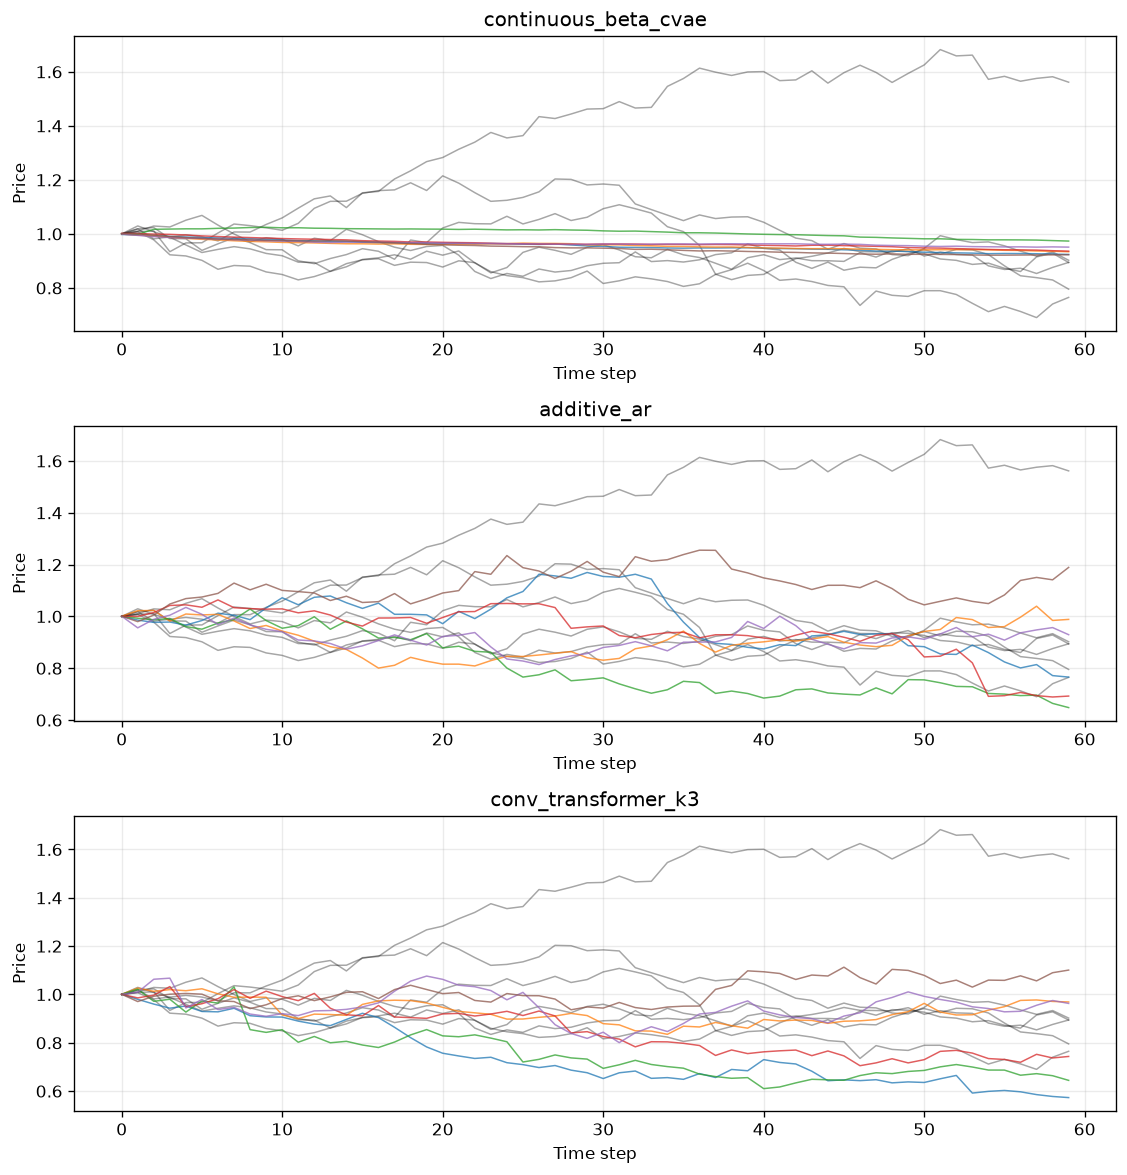

In [9]:
def load_torch_mapping(path: str | Path) -> dict[str, Any] | None:
    """Load a torch mapping with a safe default."""
    resolved = repo_path(path)
    if not (USE_LOCAL_OUTPUTS and resolved.exists()):
        return None
    payload = torch.load(resolved, map_location="cpu", weights_only=True)
    return dict(payload) if isinstance(payload, Mapping) else None


def squeeze_path_tensor(values: torch.Tensor) -> torch.Tensor:
    """Return [batch, time] float tensor."""
    tensor = values.detach().cpu().float()
    if tensor.ndim == 3 and tensor.shape[-1] == 1:
        tensor = tensor[..., 0]
    if tensor.ndim != 2:
        raise ValueError(
            f"Expected path tensor with rank 2 or [batch, time, 1], got {tuple(values.shape)}"
        )
    return tensor


def payload_prices(payload: Mapping[str, Any], prefix: str) -> torch.Tensor | None:
    """Return price paths for real or generated payload entries."""
    key_candidates = {
        "real": ("real_prices", "real_data"),
        "generated": ("generated_prices", "fake_data", "decoded_paths"),
        "reconstructed": ("reconstructed_prices", "recon_data"),
    }[prefix]
    for key in key_candidates:
        value = payload.get(key)
        if isinstance(value, torch.Tensor):
            paths = squeeze_path_tensor(value)
            if bool((paths > 0.0).all()):
                return paths
    return None


evaluation_batches = {name: load_torch_mapping(path) for name, path in LOCAL_BATCH_PATHS.items()}
evaluation_batches = {
    name: payload for name, payload in evaluation_batches.items() if payload is not None
}

if not evaluation_batches:
    display(Markdown("No local `evaluation_batch.pt` files found. Sample-path plots are skipped."))
else:
    fig, axes = plt.subplots(
        len(evaluation_batches), 1, figsize=(9.5, 3.3 * len(evaluation_batches)), squeeze=False
    )
    for ax, (name, payload) in zip(axes[:, 0], evaluation_batches.items(), strict=True):
        real = payload_prices(payload, "real")
        generated = payload_prices(payload, "generated")
        if real is None or generated is None:
            ax.text(0.02, 0.5, f"{name}: no real/generated price tensors", transform=ax.transAxes)
            continue
        for path in real[:6]:
            ax.plot(path.numpy(), color="black", alpha=0.35, linewidth=0.9)
        for path in generated[:6]:
            ax.plot(path.numpy(), alpha=0.75, linewidth=0.9)
        ax.set_title(name)
        ax.set_xlabel("Time step")
        ax.set_ylabel("Price")
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## 9. Plot return histograms and tail quantiles

The histograms use decoder-space log returns when present; otherwise they fall back to one-step log returns from price paths.


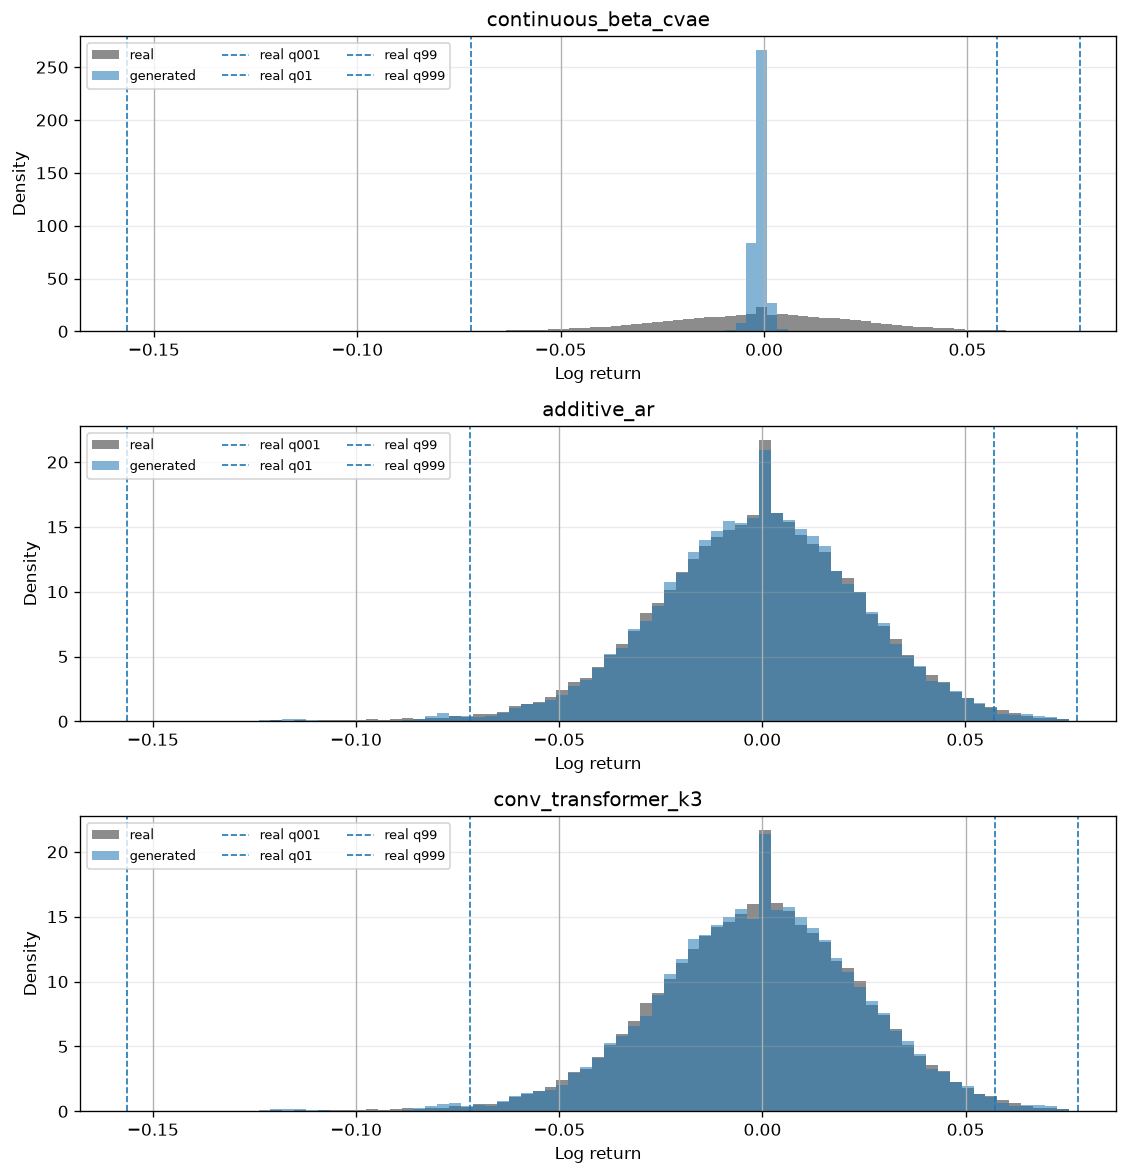

In [10]:
def payload_returns(payload: Mapping[str, Any], prefix: str) -> torch.Tensor | None:
    """Return flattened log returns for real or generated payload entries."""
    decoder_keys = {
        "real": ("real_decoder_space",),
        "generated": ("generated_decoder_space", "decoded_decoder_space"),
    }[prefix]
    for key in decoder_keys:
        value = payload.get(key)
        if isinstance(value, torch.Tensor):
            return squeeze_path_tensor(value).reshape(-1)
    prices = payload_prices(payload, prefix)
    if prices is not None:
        return compute_log_returns(prices.unsqueeze(-1)).reshape(-1).detach().cpu()
    return None


if not evaluation_batches:
    display(Markdown("No local batches found. Return histograms are skipped."))
else:
    fig, axes = plt.subplots(
        len(evaluation_batches), 1, figsize=(9.5, 3.3 * len(evaluation_batches)), squeeze=False
    )
    for ax, (name, payload) in zip(axes[:, 0], evaluation_batches.items(), strict=True):
        real_returns = payload_returns(payload, "real")
        generated_returns = payload_returns(payload, "generated")
        if real_returns is None or generated_returns is None:
            ax.text(0.02, 0.5, f"{name}: no return tensors", transform=ax.transAxes)
            continue
        real_np = real_returns.float().numpy()
        generated_np = generated_returns.float().numpy()
        bins = np.linspace(
            np.quantile(np.concatenate([real_np, generated_np]), 0.001),
            np.quantile(np.concatenate([real_np, generated_np]), 0.999),
            80,
        )
        ax.hist(real_np, bins=bins, density=True, alpha=0.45, label="real", color="black")
        ax.hist(generated_np, bins=bins, density=True, alpha=0.55, label="generated")
        for quantile, label in zip(
            (0.001, 0.01, 0.99, 0.999), ("q001", "q01", "q99", "q999"), strict=True
        ):
            ax.axvline(
                float(torch.quantile(real_returns.float(), quantile)),
                linestyle="--",
                linewidth=1.0,
                label=f"real {label}",
            )
        ax.set_title(name)
        ax.set_xlabel("Log return")
        ax.set_ylabel("Density")
        ax.legend(ncol=3, fontsize=8)
        ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## 10. Plot detected jump-count histograms

Jump tensors from local evaluation batches are used when available. Otherwise jumps are detected from robust return outliers.


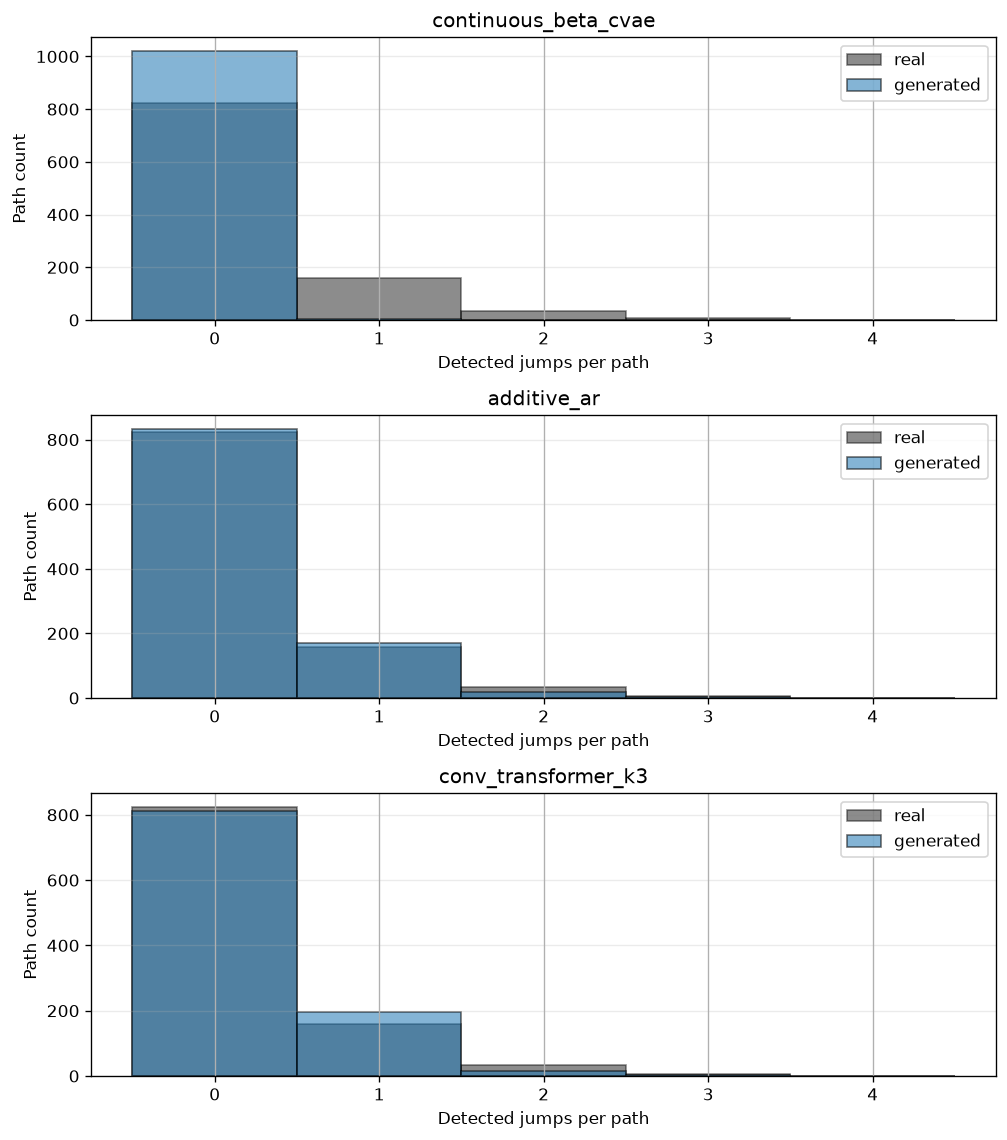

In [11]:
def payload_jumps(payload: Mapping[str, Any], prefix: str) -> torch.Tensor | None:
    """Return [batch, time] jump indicators from payload tensors or robust detection."""
    key_candidates = {
        "real": ("real_jumps",),
        "generated": ("generated_jumps",),
    }[prefix]
    for key in key_candidates:
        value = payload.get(key)
        if isinstance(value, torch.Tensor):
            return squeeze_path_tensor(value.float()).bool()
    prices = payload_prices(payload, prefix)
    if prices is not None:
        return squeeze_path_tensor(detect_jumps_from_returns(prices.unsqueeze(-1))).bool()
    returns = payload_returns(payload, prefix)
    if returns is None:
        return None
    return None


if not evaluation_batches:
    display(Markdown("No local batches found. Jump-count histograms are skipped."))
else:
    fig, axes = plt.subplots(
        len(evaluation_batches), 1, figsize=(8.5, 3.2 * len(evaluation_batches)), squeeze=False
    )
    for ax, (name, payload) in zip(axes[:, 0], evaluation_batches.items(), strict=True):
        real_jumps = payload_jumps(payload, "real")
        generated_jumps = payload_jumps(payload, "generated")
        if real_jumps is None or generated_jumps is None:
            ax.text(0.02, 0.5, f"{name}: no jump indicators", transform=ax.transAxes)
            continue
        real_counts = real_jumps.sum(dim=1).numpy()
        generated_counts = generated_jumps.sum(dim=1).numpy()
        max_count = int(max(real_counts.max(initial=0), generated_counts.max(initial=0)))
        bins = np.arange(0, max_count + 2) - 0.5
        ax.hist(real_counts, bins=bins, alpha=0.45, label="real", edgecolor="black", color="black")
        ax.hist(generated_counts, bins=bins, alpha=0.55, label="generated", edgecolor="black")
        ax.set_title(name)
        ax.set_xlabel("Detected jumps per path")
        ax.set_ylabel("Path count")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## 11. Codebook and latent geometry

This section uses the hidden128 log-return cb64 tokenizer only when local tokenizer and token-data artefacts exist. The PCA projection is always attempted for available codebook vectors; Voronoi cells are drawn only when SciPy is available and the projection is well conditioned.


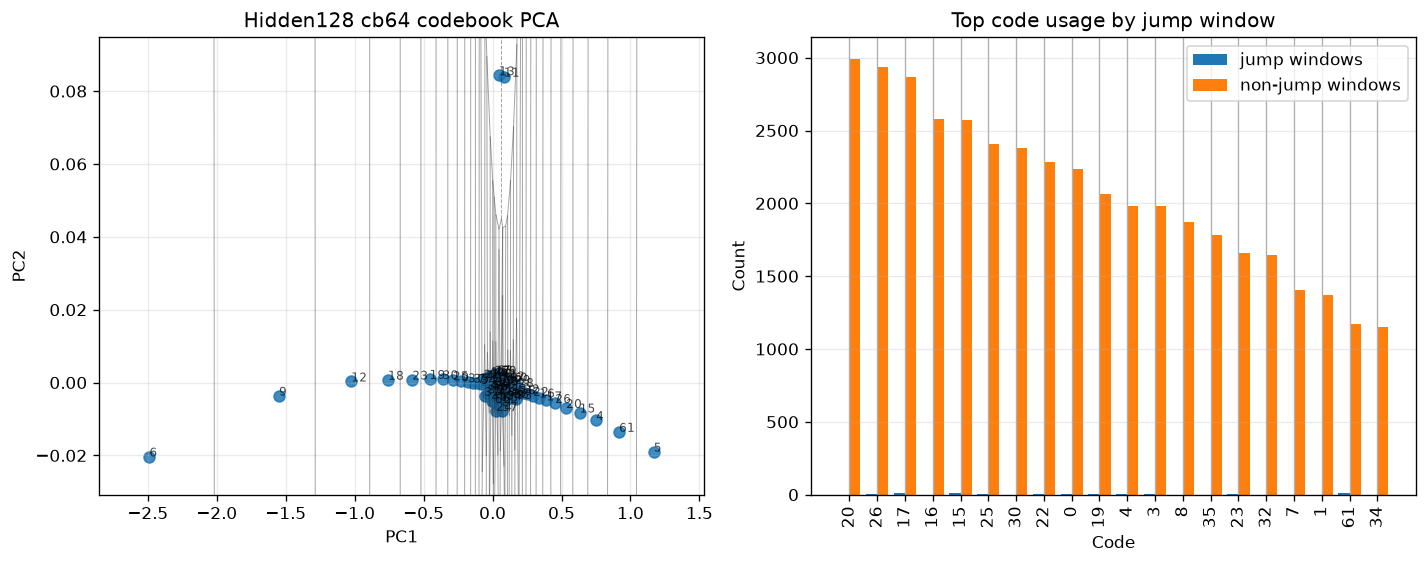

In [12]:
def load_codebook_vectors(tokenizer_dir: Path) -> np.ndarray | None:
    """Load codebook vectors from a trained tokenizer checkpoint."""
    checkpoint_path = repo_path(tokenizer_dir) / "tokenizer.pt"
    if not (USE_LOCAL_OUTPUTS and checkpoint_path.exists()):
        return None
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    if not isinstance(checkpoint, Mapping):
        return None
    state = checkpoint.get("model_state_dict")
    if not isinstance(state, Mapping):
        return None
    for key in (
        "quantizer.backend._codebook.embed",
        "quantizer.backend._codebook.embed_avg",
    ):
        value = state.get(key)
        if isinstance(value, torch.Tensor):
            vectors = value.detach().cpu().float()
            if vectors.ndim == 3 and vectors.shape[0] == 1:
                vectors = vectors[0]
            return vectors.numpy()
    return None


def pca_project(vectors: np.ndarray) -> np.ndarray:
    """Project vectors to two dimensions with sklearn PCA or an SVD fallback."""
    centred = vectors - vectors.mean(axis=0, keepdims=True)
    if PCA is not None:
        return PCA(n_components=2).fit_transform(centred)
    _, _, vh = np.linalg.svd(centred, full_matrices=False)
    return centred @ vh[:2].T


def token_usage_by_jump_window(token_dir: Path) -> tuple[np.ndarray, np.ndarray] | None:
    """Return code usage counts for detected jump and non-jump windows."""
    token_path = repo_path(token_dir) / "eval_tokens.pt"
    if not (USE_LOCAL_OUTPUTS and token_path.exists()):
        return None
    payload = torch.load(token_path, map_location="cpu", weights_only=True)
    if not isinstance(payload, Mapping) or "indices" not in payload or "data" not in payload:
        return None
    indices = payload["indices"].detach().cpu().long()
    data = payload["data"].detach().cpu().float()
    jumps = squeeze_path_tensor(detect_jumps_from_returns(data)).bool()
    if indices.ndim != 2:
        return None
    codebook_size = int(indices.max().item()) + 1 if indices.numel() else 0
    codebook_size = max(codebook_size, 64)
    jump_counts = torch.bincount(indices[jumps].reshape(-1), minlength=codebook_size)[
        :codebook_size
    ]
    non_jump_counts = torch.bincount(indices[~jumps].reshape(-1), minlength=codebook_size)[
        :codebook_size
    ]
    return jump_counts.numpy(), non_jump_counts.numpy()


codebook_vectors = load_codebook_vectors(TOKENIZER_DIR)
usage_pair = token_usage_by_jump_window(TOKEN_DATA_DIR)

if codebook_vectors is None:
    display(
        Markdown(
            f"No local tokenizer codebook found at `{display_path(repo_path(TOKENIZER_DIR))}`."
        )
    )
else:
    projected = pca_project(codebook_vectors)
    fig, axes = plt.subplots(
        1, 2 if usage_pair is not None else 1, figsize=(12, 4.8), squeeze=False
    )
    ax = axes[0, 0]
    ax.scatter(projected[:, 0], projected[:, 1], s=42, alpha=0.85)
    for index, (x_value, y_value) in enumerate(projected):
        ax.text(x_value, y_value, str(index), fontsize=7, alpha=0.72)
    if Voronoi is not None and voronoi_plot_2d is not None and projected.shape[0] >= 4:
        try:
            vor = Voronoi(projected)
            voronoi_plot_2d(
                vor, ax=ax, show_vertices=False, line_width=0.6, line_alpha=0.35, point_size=0
            )
        except Exception as exc:
            print(f"Voronoi skipped: {exc}")
    ax.set_title("Hidden128 cb64 codebook PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)

    if usage_pair is not None:
        jump_counts, non_jump_counts = usage_pair
        usage_ax = axes[0, 1]
        total = jump_counts + non_jump_counts
        top_codes = np.argsort(total)[-20:][::-1]
        x_positions = np.arange(len(top_codes))
        usage_ax.bar(x_positions - 0.2, jump_counts[top_codes], width=0.4, label="jump windows")
        usage_ax.bar(
            x_positions + 0.2, non_jump_counts[top_codes], width=0.4, label="non-jump windows"
        )
        usage_ax.set_xticks(x_positions)
        usage_ax.set_xticklabels([str(code) for code in top_codes], rotation=90)
        usage_ax.set_title("Top code usage by jump window")
        usage_ax.set_xlabel("Code")
        usage_ax.set_ylabel("Count")
        usage_ax.legend()
        usage_ax.grid(True, axis="y", alpha=0.25)
    else:
        print(f"No local token data found at {display_path(repo_path(TOKEN_DATA_DIR))}.")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## 12. Summary

Use the registered metadata as the stable comparison baseline. Local output summaries can enrich the notebook with seed-0 plots and geometry, but they are intentionally not required and must stay under ignored `outputs/` paths. The current registry marks the causal conv-transformer k3 prior as the selected discrete research candidate under the balanced/smooth profile, while the additive AR prior remains the required jump-profile ablation. The tiny conv-transformer is an optional efficiency candidate that improves jump-count and inter-arrival means but loses the balanced smooth profile; notebooks keep k3 as the default unless users explicitly choose a different candidate. The continuous log-return BetaCVAE comparator is valid but weak on sparse jumps and lower-tail behaviour.
